# CNN Analysis Notebook

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if (ROOT / 'src').exists():
    pass
elif ROOT.name == 'notebooks' and ROOT.parent.name == 'src':
    ROOT = ROOT.parents[1]
elif (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
else:
    raise RuntimeError('Could not resolve repository root.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image as IPImage, display
from src.cnn.config import load_cnn_config
from src.cnn.data import count_by_class, load_cnn_dataset


In [2]:
config = load_cnn_config(ROOT / "configs/cnn/base.json", check_data=True)
dataset = load_cnn_dataset(config)
report_dir = ROOT / "reports/cnn"

print(config.project)
print(config.input_shape)
print(config.data.class_names)

cnn_intel_image_classification
(128, 128, 3)
('buildings', 'forest', 'glacier', 'mountain', 'sea', 'street')


## Dataset

In [3]:
splits = {
    "train": dataset.train,
    "validation": dataset.validation,
    "test": dataset.test,
}

rows = []
for split, records in splits.items():
    counts = count_by_class(records, config.data.class_names)
    for class_name, count in counts.items():
        rows.append({"split": split, "class_name": class_name, "count": count})

dataset_distribution = pd.DataFrame(rows)
display(dataset_distribution.pivot(index="class_name", columns="split", values="count"))

split,test,train,validation
class_name,,,
buildings,437,1753,438
forest,474,1817,454
glacier,553,1923,481
mountain,525,2010,502
sea,510,1819,455
street,501,1906,476


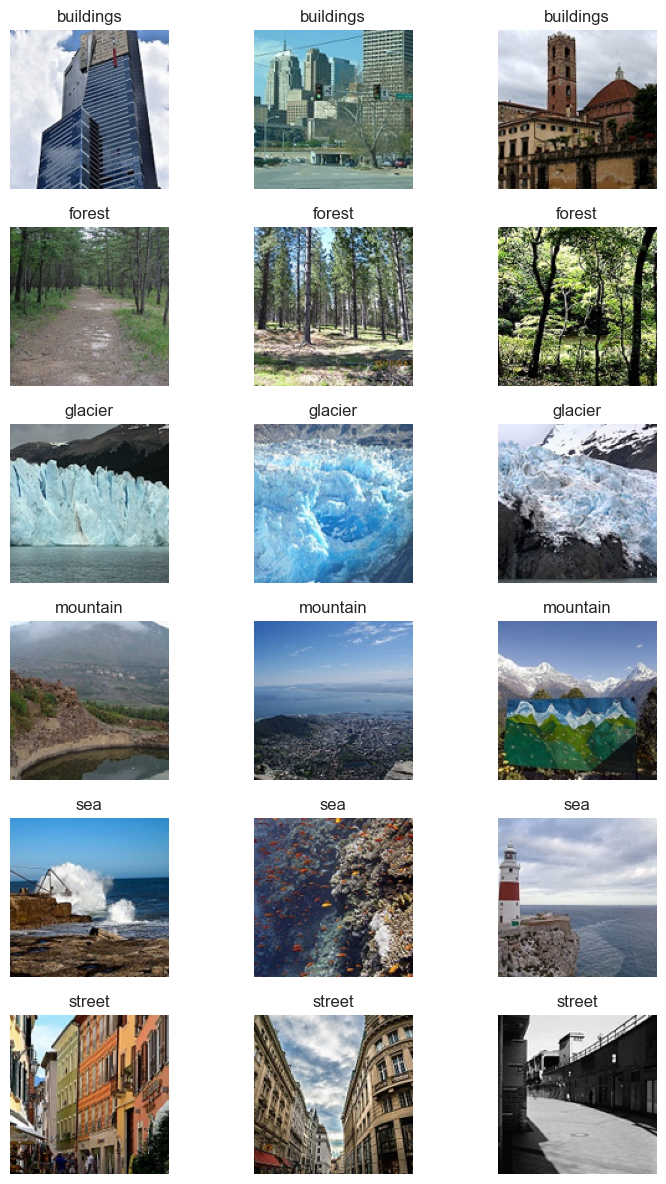

In [4]:
fig, axes = plt.subplots(len(config.data.class_names), 3, figsize=(8, 12))

for row, class_name in enumerate(config.data.class_names):
    records = [record for record in dataset.test if record.class_name == class_name][:3]
    for col, record in enumerate(records):
        image = Image.open(record.path).convert("RGB").resize(config.data.image_size)
        axes[row, col].imshow(image)
        axes[row, col].axis("off")
        axes[row, col].set_title(class_name)

plt.tight_layout()
plt.show()

## Hasil 16 Eksperimen Conv2D Shared

In [5]:
shared_details = pd.read_csv(report_dir / "shared_experiment_details.csv")
hyperparameter_effects = pd.read_csv(report_dir / "shared_hyperparameter_effects.csv")
best_shared = pd.read_csv(report_dir / "best_shared_architecture.csv")
shared_history = pd.read_csv(report_dir / "shared_training_history.csv")

display(best_shared)
display(shared_details.head(16))

,rank,run_id,status,conv_layer_count,filter_profile,kernel_profile,pooling_type,params,loss,sparse_categorical_accuracy,macro_f1,model_dir
0,1,shared_l2_f32-64_k3x3-3x3_max,trained,2,32-64,3x3-3x3,max,7393094,1.589521,0.78546,0.786172,models/cnn/shared_l2_f32-64_k3x3-3x3_max


,rank,run_id,status,conv_layer_count,filter_profile,kernel_profile,pooling_type,params,loss,sparse_categorical_accuracy,macro_f1,model_dir
0,1,shared_l2_f32-64_k3x3-3x3_max,trained,2,32-64,3x3-3x3,max,7393094,1.589521,0.785460,0.786172,models/cnn/shared_l2_f32-64_k3x3-3x3_max
1,2,shared_l2_f16-32_k3x3-3x3_max,trained,2,16-32,3x3-3x3,max,3692390,1.523444,0.765859,0.766328,models/cnn/shared_l2_f16-32_k3x3-3x3_max
2,3,shared_l2_f32-64_k3x3-3x3_average,trained,2,32-64,3x3-3x3,average,7393094,1.822985,0.753386,0.754050,models/cnn/shared_l2_f32-64_k3x3-3x3_average
3,4,shared_l2_f16-32_k3x3-3x3_average,trained,2,16-32,3x3-3x3,average,3692390,1.637504,0.754455,0.753900,models/cnn/shared_l2_f16-32_k3x3-3x3_average
4,5,shared_l2_f16-32_k5x5-3x3_max,trained,2,16-32,5x5-3x3,max,3693158,1.850614,0.746614,0.746805,models/cnn/shared_l2_f16-32_k5x5-3x3_max
5,6,shared_l2_f32-64_k5x5-3x3_average,trained,2,32-64,5x5-3x3,average,7394630,2.001171,0.725944,0.725757,models/cnn/shared_l2_f32-64_k5x5-3x3_average
6,7,shared_l2_f32-64_k5x5-3x3_max,trained,2,32-64,5x5-3x3,max,7394630,2.222277,0.727014,0.725695,models/cnn/shared_l2_f32-64_k5x5-3x3_max
7,8,shared_l2_f16-32_k5x5-3x3_average,trained,2,16-32,5x5-3x3,average,3693158,1.971468,0.712402,0.711977,models/cnn/shared_l2_f16-32_k5x5-3x3_average
8,9,shared_l1_f32_k3x3_max,trained,1,32,3x3,max,16258822,2.494593,0.685317,0.680948,models/cnn/shared_l1_f32_k3x3_max
9,10,shared_l1_f16_k3x3_average,trained,1,16,3x3,average,8129862,2.322990,0.665360,0.663641,models/cnn/shared_l1_f16_k3x3_average


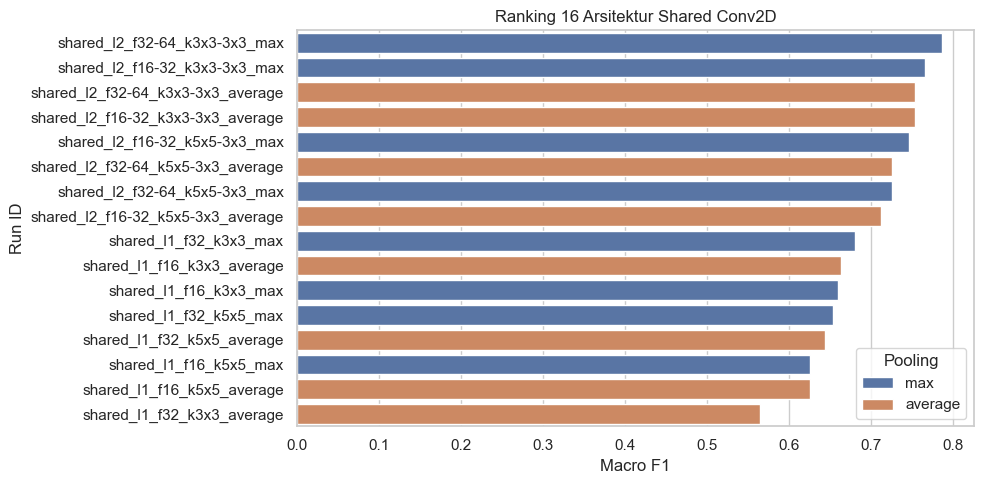

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=shared_details, x="macro_f1", y="run_id", hue="pooling_type", dodge=False)
plt.xlabel("Macro F1")
plt.ylabel("Run ID")
plt.title("Ranking 16 Arsitektur Shared Conv2D")
plt.legend(title="Pooling")
plt.tight_layout()
plt.show()

## Pengaruh Masing Masing Hyperparameter

,factor,value,experiment_count,mean_macro_f1,max_macro_f1,mean_accuracy,mean_loss,best_run_id
0,conv_layer_count,1,8,0.639669,0.680948,0.645135,2.775747,shared_l1_f32_k3x3_max
1,conv_layer_count,2,8,0.746336,0.786172,0.746392,1.827373,shared_l2_f32-64_k3x3-3x3_max
2,filter_profile,16,4,0.643656,0.663641,0.647096,2.700516,shared_l1_f16_k3x3_average
3,filter_profile,16-32,4,0.744753,0.766328,0.744833,1.745758,shared_l2_f16-32_k3x3-3x3_max
4,filter_profile,32,4,0.635681,0.680948,0.643175,2.850979,shared_l1_f32_k3x3_max
5,filter_profile,32-64,4,0.747919,0.786172,0.747951,1.908989,shared_l2_f32-64_k3x3-3x3_max
6,kernel_profile,3x3,4,0.642117,0.680948,0.651372,2.601341,shared_l1_f32_k3x3_max
7,kernel_profile,3x3-3x3,4,0.765113,0.786172,0.764790,1.643364,shared_l2_f32-64_k3x3-3x3_max
8,kernel_profile,5x5,4,0.637221,0.653796,0.638899,2.950154,shared_l1_f32_k5x5_max
9,kernel_profile,5x5-3x3,4,0.727559,0.746805,0.727994,2.011383,shared_l2_f16-32_k5x5-3x3_max


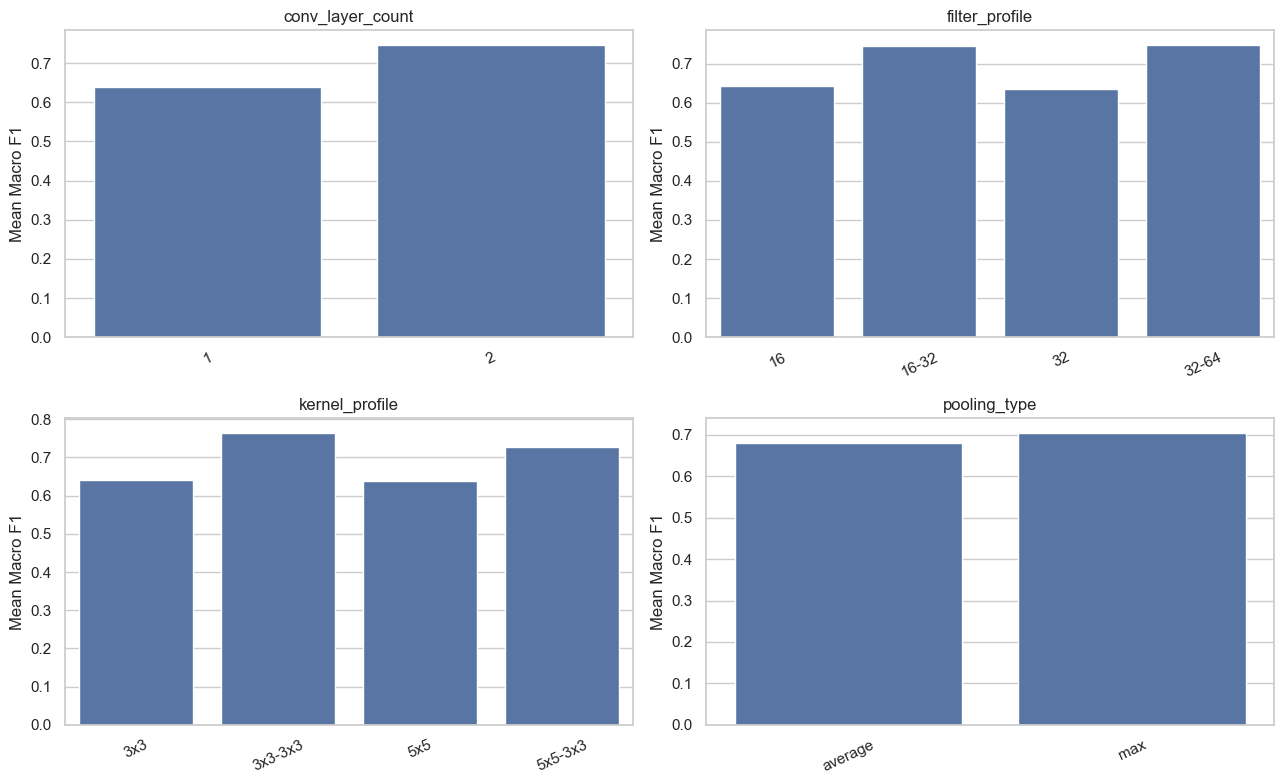

In [7]:
display(hyperparameter_effects)

factors = ["conv_layer_count", "filter_profile", "kernel_profile", "pooling_type"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for axis, factor in zip(axes.ravel(), factors):
    subset = hyperparameter_effects[hyperparameter_effects["factor"] == factor]
    sns.barplot(data=subset, x="value", y="mean_macro_f1", ax=axis)
    axis.set_title(factor)
    axis.set_xlabel("")
    axis.set_ylabel("Mean Macro F1")
    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

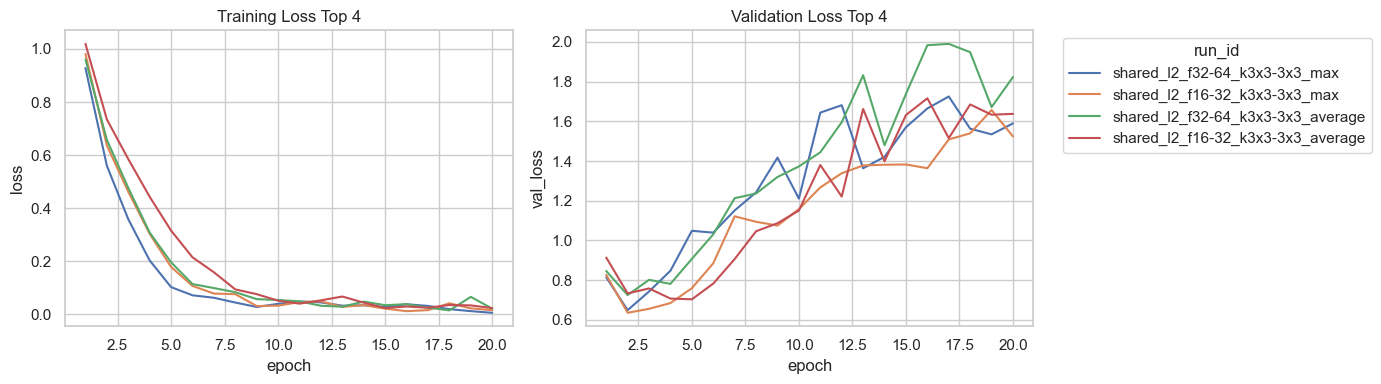

In [8]:
top_run_ids = shared_details.head(4)["run_id"].tolist()
top_history = shared_history[shared_history["run_id"].isin(top_run_ids)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=top_history, x="epoch", y="loss", hue="run_id", ax=axes[0])
sns.lineplot(data=top_history, x="epoch", y="val_loss", hue="run_id", ax=axes[1])
axes[0].set_title("Training Loss Top 4")
axes[1].set_title("Validation Loss Top 4")
axes[0].legend().remove()
axes[1].legend(title="run_id", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Keras vs Forward Propagation From Scratch

In [9]:
scratch_comparison = pd.read_csv(report_dir / "shared_scratch_test_comparison.csv")
display(scratch_comparison)

,run_id,parameter_sharing,split,samples,batches,batch_size,keras_macro_f1,scratch_macro_f1,keras_accuracy,scratch_accuracy,prediction_agreement,max_abs_diff,mean_abs_diff,seconds,weights_path
0,shared_l2_f32-64_k3x3-3x3_max,shared,test,3000,94,32,0.784462,0.784462,0.783333,0.783333,1.0,0.000002,2.130053e-08,58.083549,models/cnn/shared_l2_f32-64_k3x3-3x3_max/weights.weights.h5


Tabel di atas juga menjadi bukti batch inference untuk forward scratch: model dievaluasi pada 3000 gambar test dengan batch size 32.

## Shared vs Non-shared Parameter

Arsitektur non-shared dibuat dari arsitektur shared terbaik, lalu semua `Conv2D` diganti menjadi `LocallyConnected2D`. Bobot untuk forward scratch tidak ditukar antar tipe layer: scratch shared membaca bobot dari model Keras shared, sedangkan scratch non-shared membaca bobot dari model Keras non-shared yang dilatih dengan arsitektur ekuivalen. Ini perlu karena bentuk bobot `Conv2D` dan `LocallyConnected2D` berbeda.

,parameter_sharing,run_id,base_run_id,status,model_dir,params,loss,sparse_categorical_accuracy,macro_f1
0,shared,shared_l2_f32-64_k3x3-3x3_max,shared_l2_f32-64_k3x3-3x3_max,trained,models/cnn/shared_l2_f32-64_k3x3-3x3_max,7393094,1.589521,0.785460,0.786172
1,nonshared,nonshared_l2_f32-64_k3x3-3x3_max,shared_l2_f32-64_k3x3-3x3_max,trained,models/cnn/nonshared_l2_f32-64_k3x3-3x3_max,90422214,0.887034,0.674982,0.674527


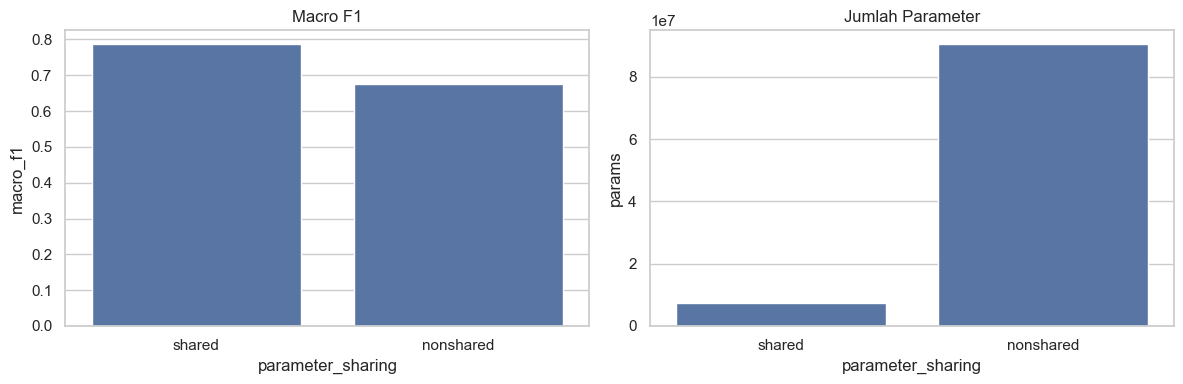

In [10]:
parameter_sharing = pd.read_csv(report_dir / "parameter_sharing_comparison.csv")
parameter_history = pd.read_csv(report_dir / "parameter_sharing_history.csv")

display(parameter_sharing)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=parameter_sharing, x="parameter_sharing", y="macro_f1", ax=axes[0])
sns.barplot(data=parameter_sharing, x="parameter_sharing", y="params", ax=axes[1])
axes[0].set_title("Macro F1")
axes[1].set_title("Jumlah Parameter")
plt.tight_layout()
plt.show()

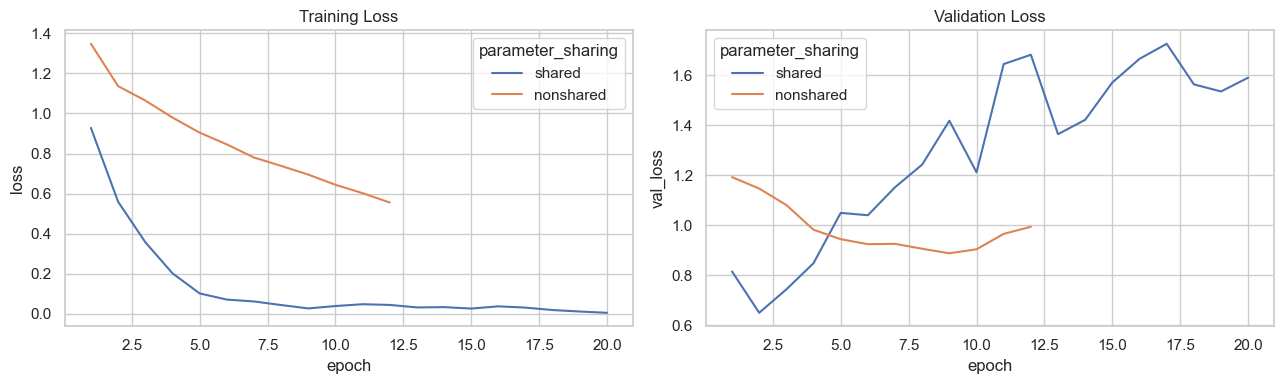

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=parameter_history, x="epoch", y="loss", hue="parameter_sharing", ax=axes[0])
sns.lineplot(data=parameter_history, x="epoch", y="val_loss", hue="parameter_sharing", ax=axes[1])
axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")
plt.tight_layout()
plt.show()

## Bonus CNN: Feature Maps dan Grad-CAM

In [12]:
visualization_summary = pd.read_csv(report_dir / "visualization_summary.csv")
display(visualization_summary)

,run_id,split,image_path,true_class,layer_name,predicted_class,is_correct,confidence,feature_maps_path,grad_cam_path
0,shared_l2_f32-64_k3x3-3x3_max,test,dataset/seg_test/buildings/20057.jpg,buildings,conv2d_2,buildings,True,1.000000,reports/cnn/visualizations/buildings_20057_conv2d_2_feature_maps.png,reports/cnn/visualizations/buildings_20057_conv2d_2_grad_cam.png
1,shared_l2_f32-64_k3x3-3x3_max,test,dataset/seg_test/forest/20056.jpg,forest,conv2d_2,forest,True,0.999745,reports/cnn/visualizations/forest_20056_conv2d_2_feature_maps.png,reports/cnn/visualizations/forest_20056_conv2d_2_grad_cam.png
2,shared_l2_f32-64_k3x3-3x3_max,test,dataset/seg_test/glacier/20059.jpg,glacier,conv2d_2,glacier,True,1.000000,reports/cnn/visualizations/glacier_20059_conv2d_2_feature_maps.png,reports/cnn/visualizations/glacier_20059_conv2d_2_grad_cam.png
3,shared_l2_f32-64_k3x3-3x3_max,test,dataset/seg_test/mountain/20058.jpg,mountain,conv2d_2,sea,False,0.448736,reports/cnn/visualizations/mountain_20058_conv2d_2_feature_maps.png,reports/cnn/visualizations/mountain_20058_conv2d_2_grad_cam.png
4,shared_l2_f32-64_k3x3-3x3_max,test,dataset/seg_test/sea/20072.jpg,sea,conv2d_2,sea,True,0.999997,reports/cnn/visualizations/sea_20072_conv2d_2_feature_maps.png,reports/cnn/visualizations/sea_20072_conv2d_2_grad_cam.png
5,shared_l2_f32-64_k3x3-3x3_max,test,dataset/seg_test/street/20066.jpg,street,conv2d_2,forest,False,0.999911,reports/cnn/visualizations/street_20066_conv2d_2_feature_maps.png,reports/cnn/visualizations/street_20066_conv2d_2_grad_cam.png


buildings -> buildings | correct=True


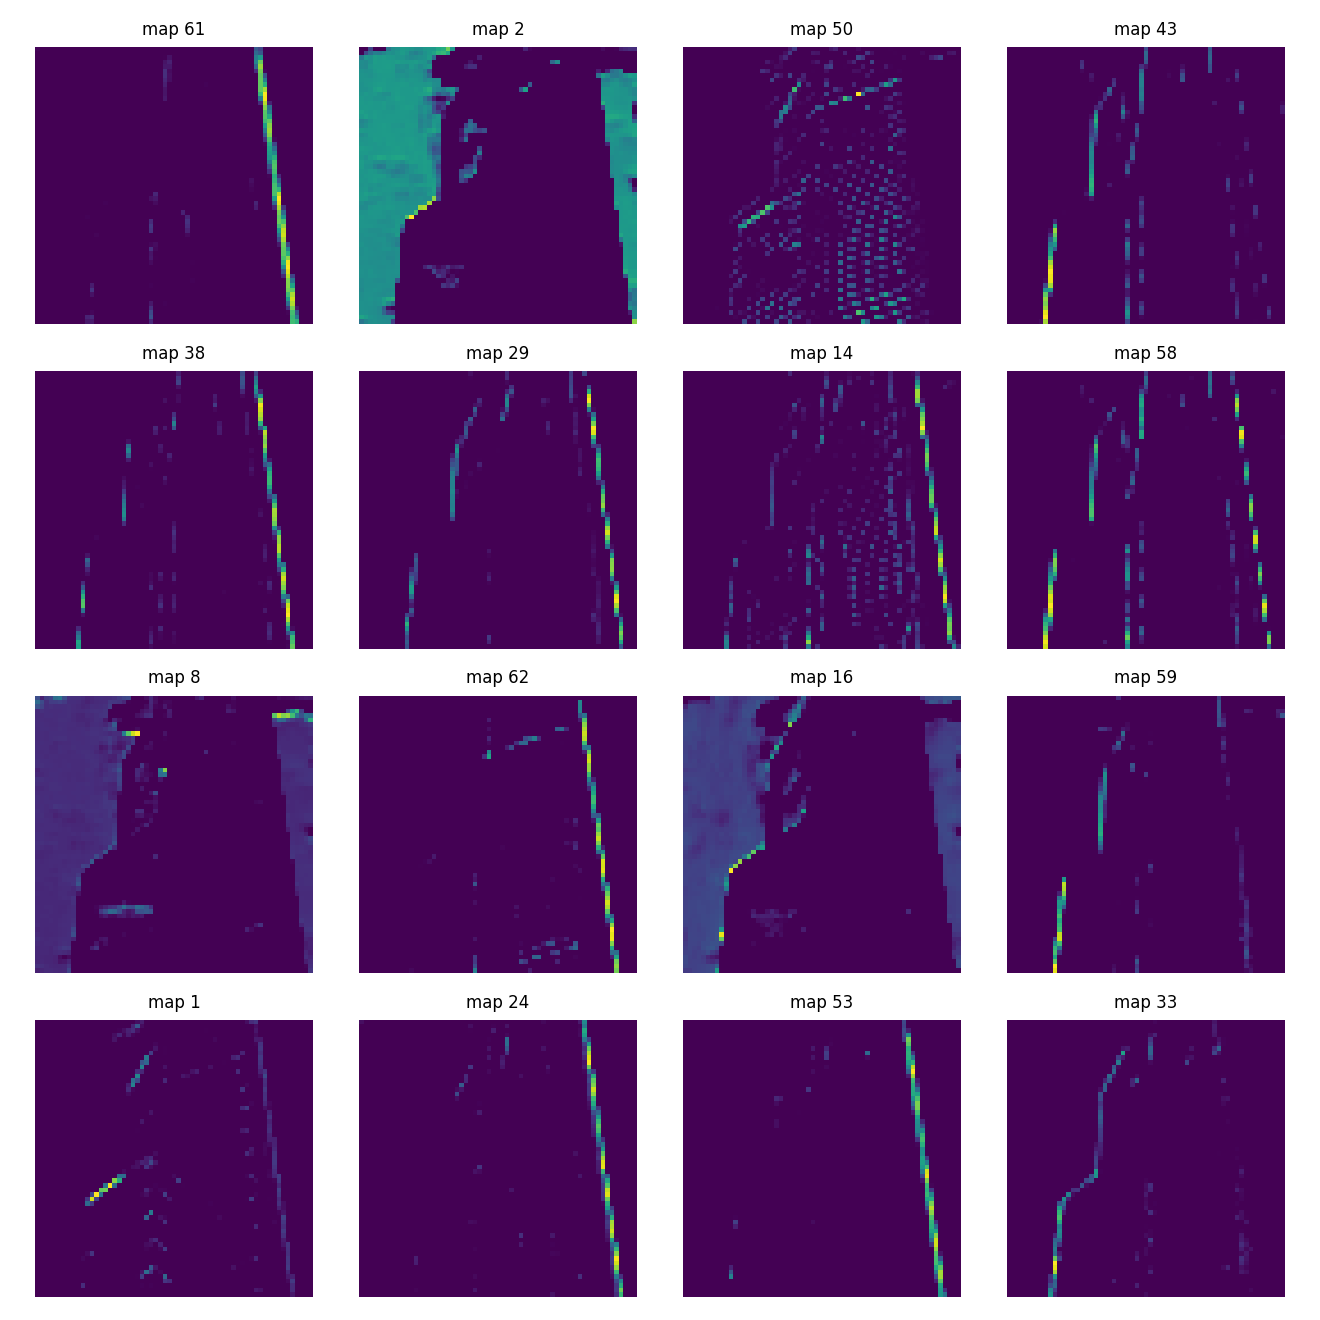

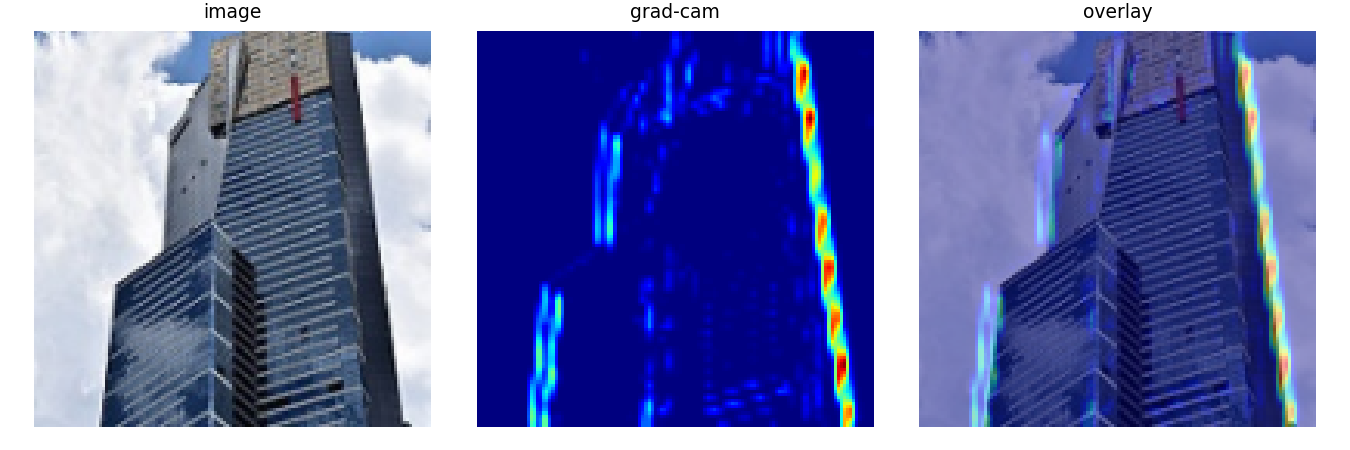

forest -> forest | correct=True


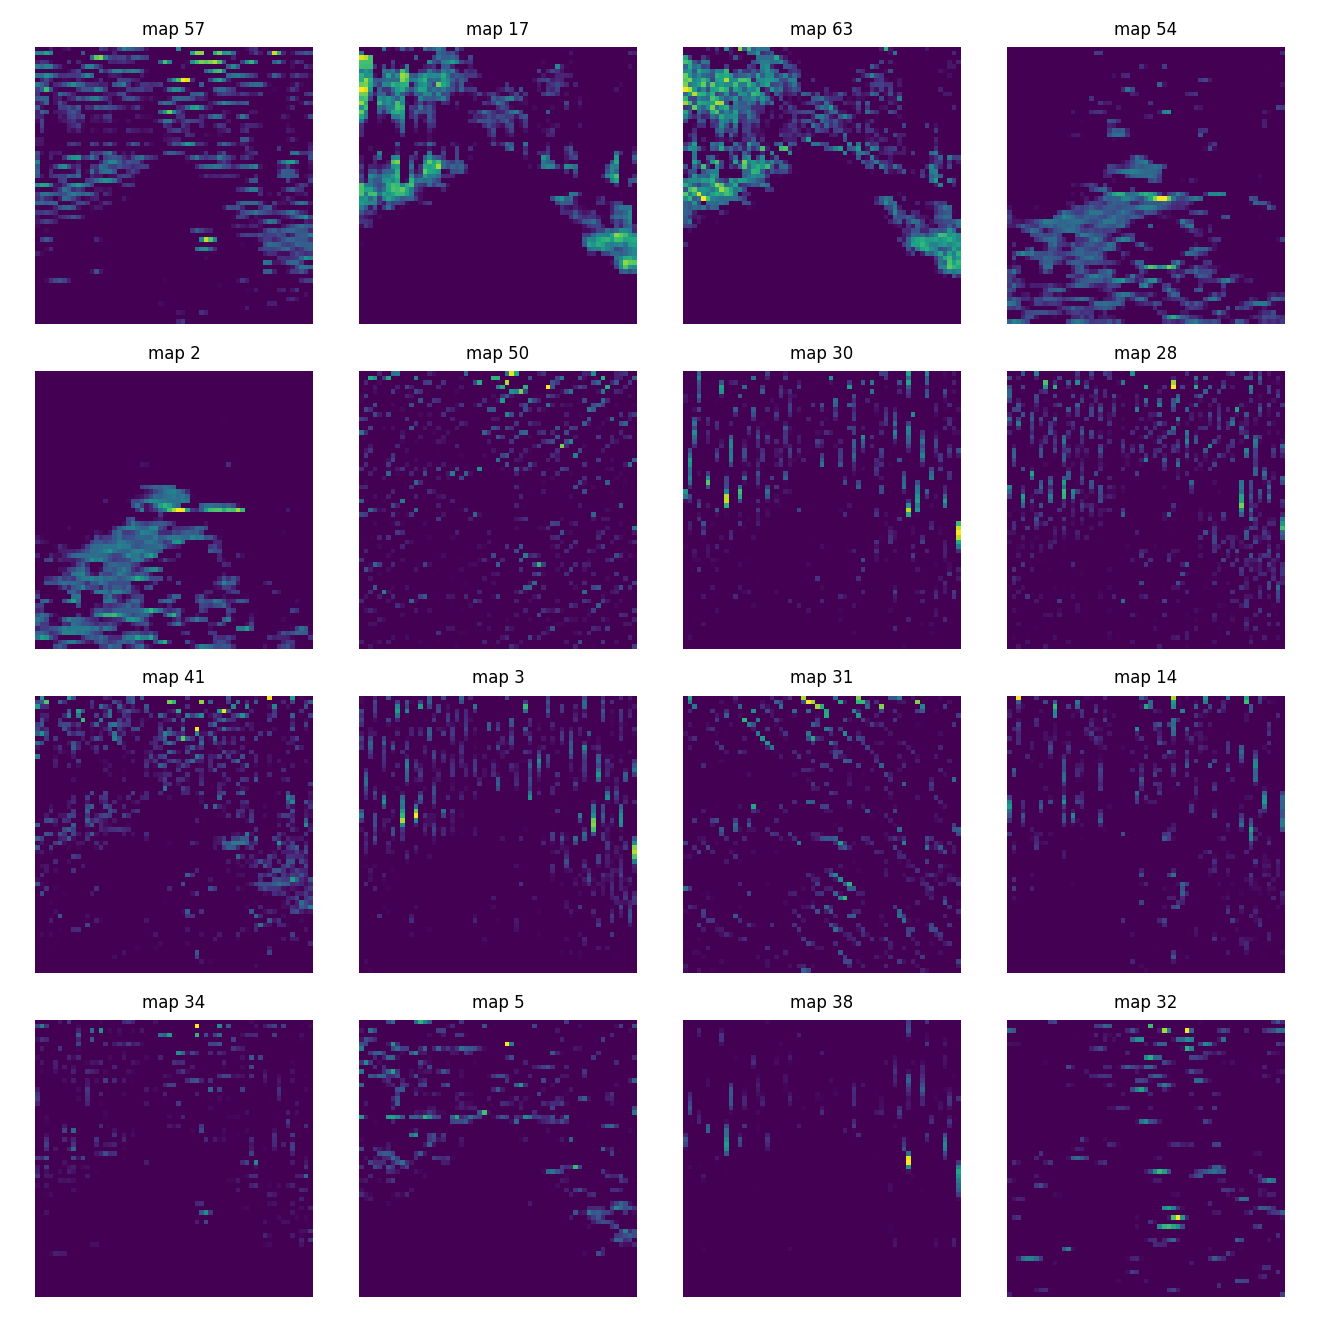

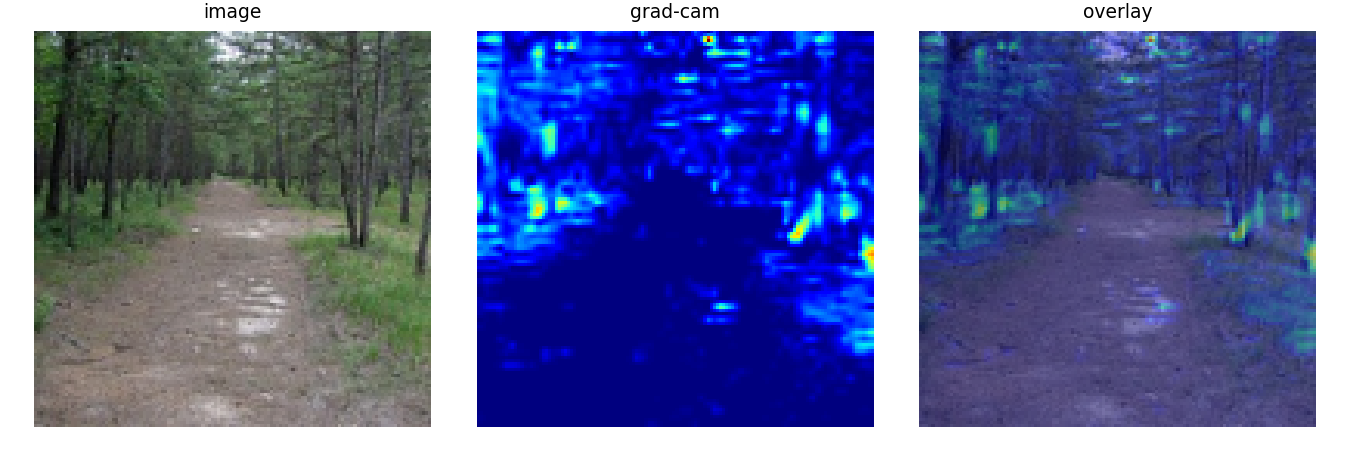

glacier -> glacier | correct=True


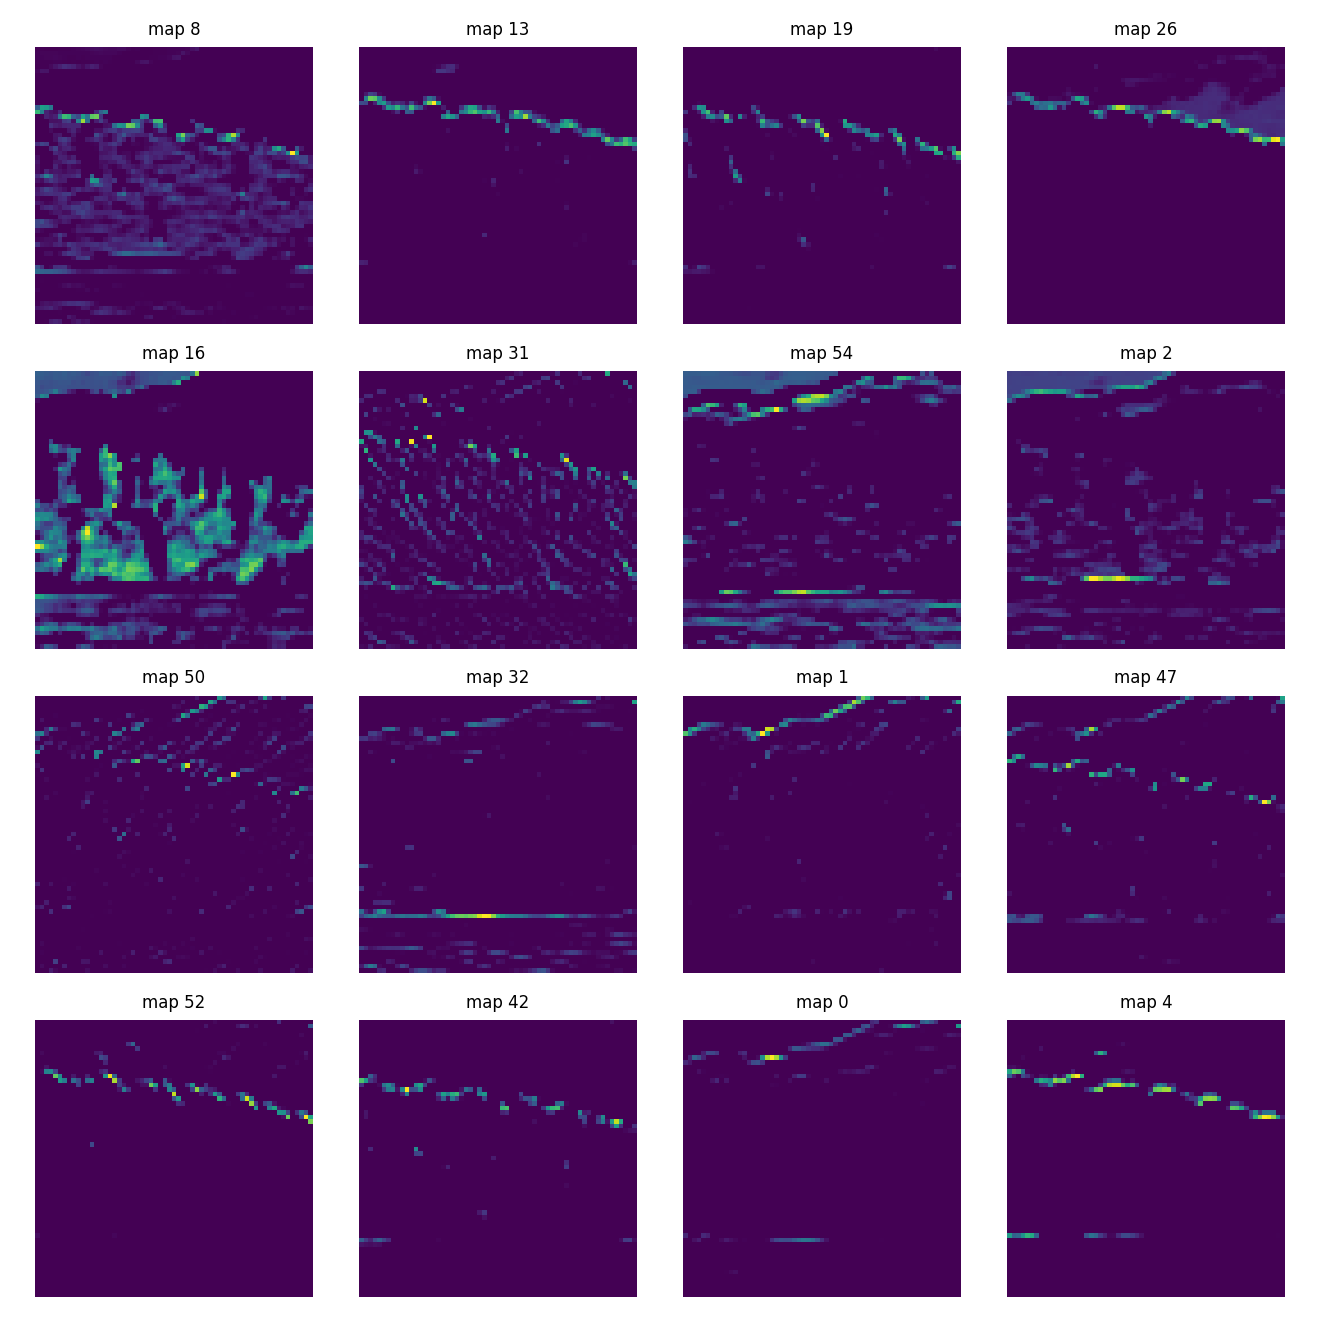

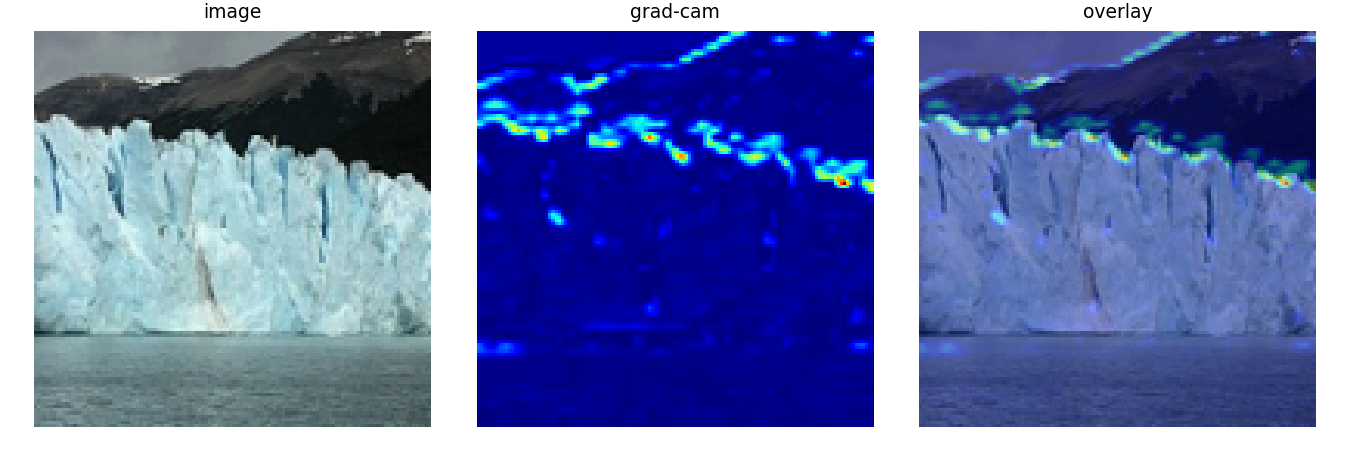

In [13]:
for _, row in visualization_summary.head(3).iterrows():
    print(f"{row['true_class']} -> {row['predicted_class']} | correct={row['is_correct']}")
    display(IPImage(filename=str(ROOT / row["feature_maps_path"])))
    display(IPImage(filename=str(ROOT / row["grad_cam_path"])))

## Ringkasan Demo

- Model terbaik shared adalah `shared_l2_f32-64_k3x3-3x3_max`.
- Forward scratch shared menghasilkan prediksi yang sama dengan Keras pada test set penuh.
- Non-shared memakai arsitektur ekuivalen dari best shared, tetapi mengganti semua Conv2D menjadi LocallyConnected2D.
- Non-shared memiliki parameter jauh lebih banyak, tetapi performanya lebih rendah pada eksperimen ini.
- Feature maps dan Grad-CAM menunjukkan bagian gambar yang paling memengaruhi prediksi model CNN.